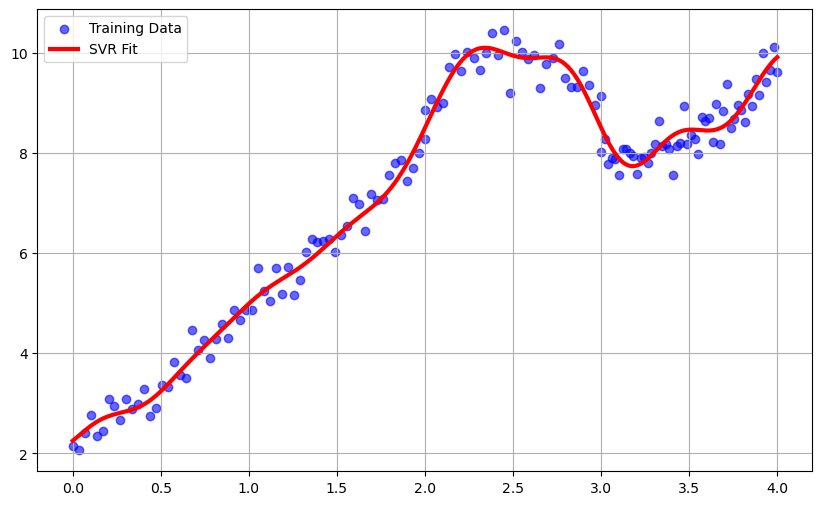

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

# ============================================================
# Load data
# ============================================================
data = pd.read_csv("polynomial_data.csv")

X = data["x_train"].values.reshape(-1,1)
y = data["y_train"].values

# ============================================================
# Kernels
# ============================================================

def linear_kernel(X1, X2):
    return X1 @ X2.T

def rbf_kernel(X1, X2, gamma=1.0):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1,1)
        + np.sum(X2**2, axis=1)
        - 2*np.dot(X1, X2.T)
    )
    return np.exp(-gamma * sq_dists)

# ============================================================
# SVR Dual Solver
# ============================================================

def train_svr_dual(
        X,
        y,
        C=10.0,
        epsilon=0.2,
        gamma=1.0,
        kernel_fn=rbf_kernel):

    n = len(y)

    # Kernel matrix
    K = kernel_fn(X, X, gamma)

    # --------------------------------------------------------
    # Dual variables:
    # z = [alpha_1...alpha_n alpha*_1...alpha*_n]
    # size = 2n
    # --------------------------------------------------------

    P_top = np.hstack([K, -K])
    P_bottom = np.hstack([-K, K])
    P = np.vstack([P_top, P_bottom])

    q = np.hstack([
        epsilon*np.ones(n) - y,
        epsilon*np.ones(n) + y
    ])

    # 0 <= alpha <= C
    G = np.vstack([
        -np.eye(2*n),
         np.eye(2*n)
    ])

    h = np.hstack([
        np.zeros(2*n),
        C*np.ones(2*n)
    ])

    # equality:
    # sum(alpha - alpha*) = 0

    A = np.hstack([
        np.ones(n),
        -np.ones(n)
    ]).reshape(1,-1)

    b = np.array([0.0])

    # Convert to cvxopt
    P = matrix(P.astype(np.double))
    q = matrix(q.astype(np.double))
    G = matrix(G.astype(np.double))
    h = matrix(h.astype(np.double))
    A = matrix(A.astype(np.double))
    b = matrix(b.astype(np.double))

    solvers.options['show_progress'] = False

    sol = solvers.qp(P, q, G, h, A, b)

    z = np.ravel(sol['x'])

    alpha = z[:n]
    alpha_star = z[n:]

    coeff = alpha - alpha_star

    # --------------------------------------------------------
    # Support vectors
    # --------------------------------------------------------

    sv_mask = np.abs(coeff) > 1e-5

    sv_X = X[sv_mask]
    sv_y = y[sv_mask]
    sv_coeff = coeff[sv_mask]

    # --------------------------------------------------------
    # Compute bias
    # --------------------------------------------------------

    K_sv = kernel_fn(sv_X, sv_X, gamma)

    b_vals = []

    for i in range(len(sv_X)):
        pred = np.sum(sv_coeff * K_sv[:, i])

        b_vals.append(
            sv_y[i] - pred
        )

    bias = np.mean(b_vals)

    return {
        "sv_X": sv_X,
        "sv_coeff": sv_coeff,
        "bias": bias,
        "gamma": gamma,
        "kernel_fn": kernel_fn
    }

# ============================================================
# Prediction
# ============================================================

def predict_svr(X_test, model):

    K = model["kernel_fn"](
        X_test,
        model["sv_X"],
        model["gamma"]
    )

    return (
        K @ model["sv_coeff"]
        + model["bias"]
    )

# ============================================================
# Train
# ============================================================

model = train_svr_dual(
    X,
    y,
    C=100,
    epsilon=0.3,
    gamma=5.0
)

# ============================================================
# Predict smooth curve
# ============================================================

x_plot = np.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1,1)

y_pred = predict_svr(
    x_plot,
    model
)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y,
    color='blue',
    alpha=0.6,
    label='Training Data'
)

plt.plot(
    x_plot,
    y_pred,
    color='red',
    linewidth=3,
    label='SVR Fit'
)

plt.legend()
plt.grid(True)
plt.show()

## 